In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
#from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve


# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/home-credit-default-risk/sample_submission.csv
/kaggle/input/home-credit-default-risk/bureau_balance.csv
/kaggle/input/home-credit-default-risk/POS_CASH_balance.csv
/kaggle/input/home-credit-default-risk/application_train.csv
/kaggle/input/home-credit-default-risk/HomeCredit_columns_description.csv
/kaggle/input/home-credit-default-risk/application_test.csv
/kaggle/input/home-credit-default-risk/previous_application.csv
/kaggle/input/home-credit-default-risk/credit_card_balance.csv
/kaggle/input/home-credit-default-risk/installments_payments.csv
/kaggle/input/home-credit-default-risk/bureau.csv


In [2]:
!pip install scorecardpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 3.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for scorecardpy: filename=scorecardpy-0.1.9.7-py3-none-any.whl size=60629 sha256=8da8572bddbeaa4a2603768c5f3b3a58cda276fd787debc7e8ee1eb6ee95d23a
  Stored in directory: /root/.cache/pip/wheels/9f/d8/4e/61a6f4e78fe6700f66b699ab38377f0aa5b33e3ef55751ba38
Successfully built scorecardpy


## Section 1: Data Acquisition & Cleaning

1.1 Load Data

Dataset Dimensions: (307511, 122)
Target Variable Distribution in application_train:
 TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64
Column missing in test set: {'TARGET'}
Top 10 features with highest missing value percentage:
 COMMONAREA_AVG              69.872297
COMMONAREA_MODE             69.872297
COMMONAREA_MEDI             69.872297
NONLIVINGAPARTMENTS_MEDI    69.432963
NONLIVINGAPARTMENTS_MODE    69.432963
NONLIVINGAPARTMENTS_AVG     69.432963
FONDKAPREMONT_MODE          68.386172
LIVINGAPARTMENTS_AVG        68.354953
LIVINGAPARTMENTS_MEDI       68.354953
LIVINGAPARTMENTS_MODE       68.354953
dtype: float64


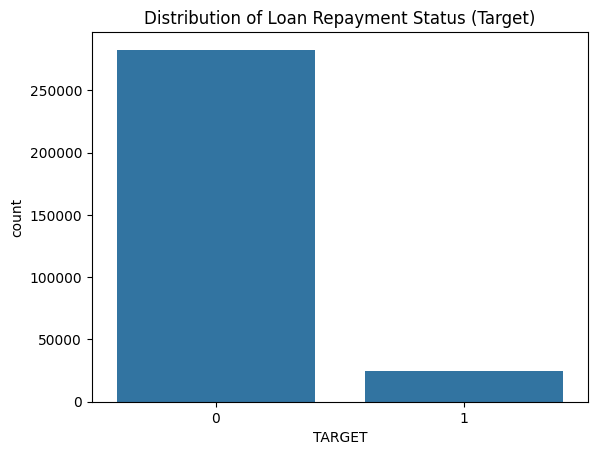

In [3]:
# Load the dataset
app_train = pd.read_csv("/kaggle/input/home-credit-default-risk/application_train.csv")
app_test = pd.read_csv("/kaggle/input/home-credit-default-risk/application_test.csv")
# Verify the scale of the dataset (307,511 rows, 122 columns)
print(f"Dataset Dimensions: {app_train.shape}")

# Check the distribution of the Target variable in appplication_train.csv (1: Default, 0: Repayment)
target_dist = app_train['TARGET'].value_counts(normalize=True)
print("Target Variable Distribution in application_train:\n", target_dist)

# Check the difference between train and test columns
# This confirms that 'TARGET' is the only missing column in test
train_cols = set(app_train.columns)
test_cols = set(app_test.columns)
missing_column = train_cols - test_cols
print(f"Column missing in test set: {missing_column}")

# Check the missing values
null_counts = app_train.isnull().sum().sort_values(ascending=False)
null_percentage = (null_counts / len(app_train)) * 100
print("Top 10 features with highest missing value percentage:\n", null_percentage.head(10))

# Visualization
sns.countplot(x='TARGET', data=app_train)
plt.title('Distribution of Loan Repayment Status (Target)')
plt.show()

1.2 Check Temporal Dependency

In [4]:
# Check Temporal Dependency: Monthly Chronological Order
# Load a sample of bureau_balance
bureau_balance = pd.read_csv('/kaggle/input/home-credit-default-risk/bureau_balance.csv')

# Select one specific credit record (SK_ID_BUREAU) to see its timeline
sample_id = bureau_balance['SK_ID_BUREAU'].iloc[0]
record_timeline = bureau_balance[bureau_balance['SK_ID_BUREAU'] == sample_id].sort_values('MONTHS_BALANCE')

print(f"Chronological records for Bureau ID {sample_id}:")
print(record_timeline[['MONTHS_BALANCE', 'STATUS']])

# Insight: Subsequent months' STATUS (e.g., C=closed, 0=no overdue(no DPD),X=unknown) 
# depends on the account's history in previous months.


Chronological records for Bureau ID 5715448:
    MONTHS_BALANCE STATUS
26             -26      X
25             -25      X
24             -24      X
23             -23      X
22             -22      X
21             -21      X
20             -20      X
19             -19      0
18             -18      0
17             -17      0
16             -16      0
15             -15      0
14             -14      0
13             -13      X
12             -12      X
11             -11      X
10             -10      0
9               -9      0
8               -8      C
7               -7      C
6               -6      C
5               -5      C
4               -4      C
3               -3      C
2               -2      C
1               -1      C
0                0      C


In [5]:
# Check Temporal Dependency: Actual Vs Expected Payments
installments = pd.read_csv('/kaggle/input/home-credit-default-risk/installments_payments.csv')

# Calculate the delay (Temporal offset)
# Positive value means late payment, negative means early payment
installments['PAYMENT_DELAY'] = installments['DAYS_ENTRY_PAYMENT'] - installments['DAYS_INSTALMENT']

# Calculate the payment difference
installments['PAYMENT_DIFF'] = installments['AMT_INSTALMENT'] - installments['AMT_PAYMENT']

print("Sample of Payment Behavior Relative to Schedule:")
print(installments[['DAYS_INSTALMENT', 'DAYS_ENTRY_PAYMENT', 'PAYMENT_DELAY']].head())

# Insight: The existence of these columns proves that 'Actual Behavior' is measured against the 'Expected Schedule'.
# All temporal variables are expressed as negative offsets relative to the current application date (T=0)
# the number is closer to 0, means the day is closer to now


Sample of Payment Behavior Relative to Schedule:
   DAYS_INSTALMENT  DAYS_ENTRY_PAYMENT  PAYMENT_DELAY
0          -1180.0             -1187.0           -7.0
1          -2156.0             -2156.0            0.0
2            -63.0               -63.0            0.0
3          -2418.0             -2426.0           -8.0
4          -1383.0             -1366.0           17.0


1.3 General Cleaning

In [6]:
# 1. Handling outliers
# Replace the anomalous value 365243 with NaN to avoid skewing the model
app_train['DAYS_EMPLOYED'] = app_train['DAYS_EMPLOYED'].replace(365243, np.nan)
app_test['DAYS_EMPLOYED'] = app_test['DAYS_EMPLOYED'].replace(365243, np.nan)

# 2. Convert date format to years 
# Derive 'YEARS_BIRTH' (Age) from 'DAYS_BIRTH'
app_train['YEARS_BIRTH'] = abs(app_train['DAYS_BIRTH']) / 365
app_test['YEARS_BIRTH'] = abs(app_test['DAYS_BIRTH']) / 365

# Derive 'YEARS_EMPLOYED' (Years of work) from 'DAYS_EMPLOYED'
app_train['YEARS_EMPLOYED'] = abs(app_train['DAYS_EMPLOYED']) / 365
app_test['YEARS_EMPLOYED'] = abs(app_test['DAYS_EMPLOYED']) / 365

## Section 2: Exploratory Data Analysis

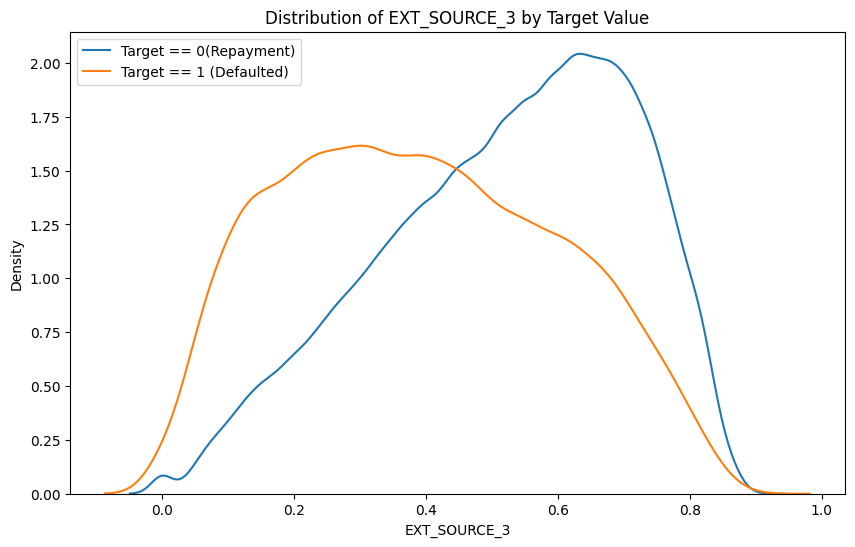

In [7]:
# 1. the distribution relationship between EXT_SOURCE_3 and TARGET.
plt.figure(figsize=(10, 6))
sns.kdeplot(app_train.loc[app_train['TARGET'] == 0, 'EXT_SOURCE_3'], label='Target == 0(Repayment)')
sns.kdeplot(app_train.loc[app_train['TARGET'] == 1, 'EXT_SOURCE_3'], label='Target == 1 (Defaulted)')
plt.title('Distribution of EXT_SOURCE_3 by Target Value')
plt.xlabel('EXT_SOURCE_3')
plt.ylabel('Density')
plt.legend()
plt.show()

Text(0.5, 1.0, 'Distribution of Ages')

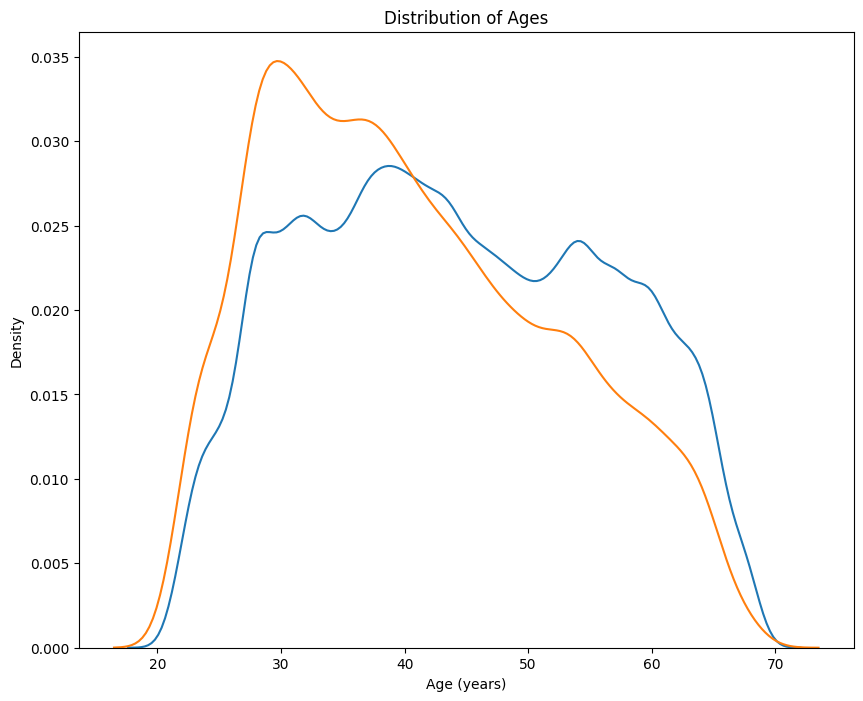

In [8]:
#2. Distribution of Ages (YEARS_BIRTH)
plt.figure(figsize=(10, 8))
sns.kdeplot(app_train.loc[app_train['TARGET'] == 0, 'YEARS_BIRTH'], label='Target == 0(Repayment)')
sns.kdeplot(app_train.loc[app_train['TARGET'] == 1, 'YEARS_BIRTH'], label='Target == 1(Default)')
plt.xlabel('Age (years)')
plt.ylabel('Density')
plt.title('Distribution of Ages')

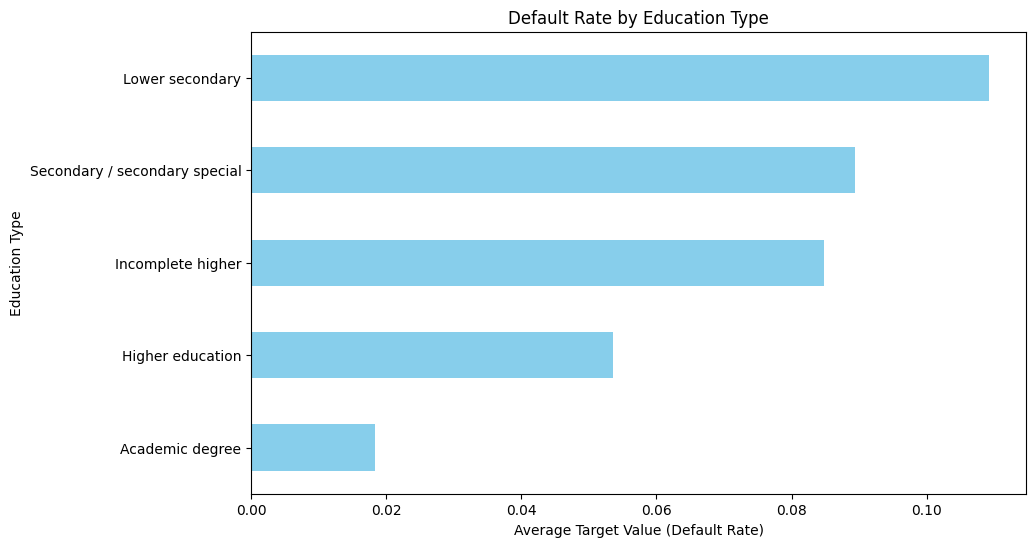

In [9]:
# 3. Default Rate by Education Type
education_groups = app_train.groupby('NAME_EDUCATION_TYPE')['TARGET'].mean().sort_values()

plt.figure(figsize=(10, 6))
education_groups.plot(kind='barh', color='skyblue')
plt.title('Default Rate by Education Type')
plt.xlabel('Average Target Value (Default Rate)')
plt.ylabel('Education Type')
plt.show()

In [10]:
# 4. Correlation Analysis
correlations = app_train.corr(numeric_only=True)['TARGET'].sort_values()

print('Top 10 Most Negatively Correlated Features:\n', correlations.head(10))
print('\nTop 10 Most Positively Correlated Features:\n', correlations.tail(10))

Top 10 Most Negatively Correlated Features:
 EXT_SOURCE_3                 -0.178919
EXT_SOURCE_2                 -0.160472
EXT_SOURCE_1                 -0.155317
YEARS_BIRTH                  -0.078239
YEARS_EMPLOYED               -0.074958
FLOORSMAX_AVG                -0.044003
FLOORSMAX_MEDI               -0.043768
FLOORSMAX_MODE               -0.043226
AMT_GOODS_PRICE              -0.039645
REGION_POPULATION_RELATIVE   -0.037227
Name: TARGET, dtype: float64

Top 10 Most Positively Correlated Features:
 REG_CITY_NOT_LIVE_CITY         0.044395
FLAG_EMP_PHONE                 0.045982
REG_CITY_NOT_WORK_CITY         0.050994
DAYS_ID_PUBLISH                0.051457
DAYS_LAST_PHONE_CHANGE         0.055218
REGION_RATING_CLIENT           0.058899
REGION_RATING_CLIENT_W_CITY    0.060893
DAYS_EMPLOYED                  0.074958
DAYS_BIRTH                     0.078239
TARGET                         1.000000
Name: TARGET, dtype: float64


## Section 3: The Dual-Pipeline Transformation

### 3.1 Pipeline A: Scorecard Development (For Logistic Regression)
* Methodology: Binning，IV Filtering,WOE Transformation.
* Procedure: We applied binning directly to the cleaned dataset. Unlike traditional machine learning pipelines, we omitted median imputation for this branch.
* Deliverable: train_woe,test_woe
* Rationale: This pipeline is designed to build a standard Credit Scorecard model. In this context, missing data (NaN) is treated as an Independent Risk Category. This is crucial because, in credit applications, the absence of information (e.g., missing employment duration) often correlates with higher default risk. By using WOE, we capture this latent risk signal rather than masking it with average values.

3.1.1 Binning

In [11]:
# Binning
# This handles both numerical and categorical variables automatically.
# It identifies optimal cut-off points to maximize the separation between 'Good' and 'Bad' clients.
import scorecardpy as sc
import warnings
warnings.filterwarnings('ignore')

# Get a list of unique values
print(app_train['ORGANIZATION_TYPE'].unique())


# ORGANIZATION_TYPE have too many unique non-numberic values, which might cause the binning process slow.
# ①keep top10 organizations from these 58 categories, we would miss out on many critically important "risk outliers.
#top_10 = app_train['ORGANIZATION_TYPE'].value_counts().nlargest(10).index
#app_train['ORGANIZATION_TYPE'] = app_train['ORGANIZATION_TYPE'].apply(lambda x: x if x in top_10 else 'Other')
#app_test['ORGANIZATION_TYPE'] = app_test['ORGANIZATION_TYPE'].apply(lambda x: x if x in top_10 else 'Other')
# ②define a mapping dictionary
#Although the industry classification was optimized, it was not included in the final linear scorecard because its IV value fell below 0.1. 
#This demonstrates the limited capacity of linear models to capture weak signals.
org_mapping = {
    'Business Entity Type 3': 'Business', 'Business Entity Type 2': 'Business', 'Business Entity Type 1': 'Business',
    'Government': 'Public', 'School': 'Public', 'Medicine': 'Public', 'Kindergarten': 'Public', 
    'University': 'Public', 'Police': 'Public', 'Military': 'Public', 'Security Ministries': 'Public', 'Emergency': 'Public',
    'Self-employed': 'Self-employed',
    'Trade: type 7': 'Trade_Services', 'Trade: type 2': 'Trade_Services', 'Trade: type 3': 'Trade_Services', 
    'Trade: type 6': 'Trade_Services', 'Trade: type 1': 'Trade_Services', 'Trade: type 5': 'Trade_Services', 'Trade: type 4': 'Trade_Services',
    'Services': 'Trade_Services', 'Hotel': 'Trade_Services', 'Restaurant': 'Trade_Services', 'Bank': 'Trade_Services', 
    'Insurance': 'Trade_Services', 'Culture': 'Trade_Services', 'Legal Services': 'Trade_Services', 'Advertising': 'Trade_Services',
    'Postal': 'Trade_Services', 'Mobile': 'Trade_Services', 'Telecom': 'Trade_Services', 'Cleaning': 'Trade_Services', 'Realtor': 'Trade_Services',
    'Industry: type 11': 'Industry_Construction', 'Industry: type 1': 'Industry_Construction', 'Industry: type 4': 'Industry_Construction',
    'Industry: type 7': 'Industry_Construction', 'Industry: type 3': 'Industry_Construction', 'Industry: type 9': 'Industry_Construction',
    'Industry: type 2': 'Industry_Construction', 'Industry: type 12': 'Industry_Construction', 'Industry: type 5': 'Industry_Construction',
    'Industry: type 10': 'Industry_Construction', 'Industry: type 13': 'Industry_Construction', 'Industry: type 8': 'Industry_Construction', 
    'Industry: type 6': 'Industry_Construction', 'Construction': 'Industry_Construction', 'Housing': 'Industry_Construction', 'Agriculture': 'Industry_Construction', 'Electricity': 'Industry_Construction',
    'Transport: type 2': 'Transport', 'Transport: type 4': 'Transport', 'Transport: type 3': 'Transport', 'Transport: type 1': 'Transport',
    'Security': 'Other', 'Other': 'Other', 'XNA': 'Other', 'Religion': 'Other'
}

# mapping
app_train['ORGANIZATION_TYPE'] = app_train['ORGANIZATION_TYPE'].map(org_mapping).fillna('Other')
app_test['ORGANIZATION_TYPE'] = app_test['ORGANIZATION_TYPE'].map(org_mapping).fillna('Other')

print(f"New categories in ORGANIZATION_TYPE: {app_train['ORGANIZATION_TYPE'].unique()}")

# This ensures the independent variables are processed for weight-of-evidence (WOE) transformation
features_to_bin = [col for col in app_train.columns if col not in ['TARGET']]

# Execute the binning process
# bin_num_limit: Set to 5 to ensure each feature has a maximum of 5 bins, 
# improving model interpretability and preventing overfitting.
bins = sc.woebin(app_train, y='TARGET', x=features_to_bin, bin_num_limit=5)

['Business Entity Type 3' 'School' 'Government' 'Religion' 'Other' 'XNA'
 'Electricity' 'Medicine' 'Business Entity Type 2' 'Self-employed'
 'Transport: type 2' 'Construction' 'Housing' 'Kindergarten'
 'Trade: type 7' 'Industry: type 11' 'Military' 'Services'
 'Security Ministries' 'Transport: type 4' 'Industry: type 1' 'Emergency'
 'Security' 'Trade: type 2' 'University' 'Transport: type 3' 'Police'
 'Business Entity Type 1' 'Postal' 'Industry: type 4' 'Agriculture'
 'Restaurant' 'Culture' 'Hotel' 'Industry: type 7' 'Trade: type 3'
 'Industry: type 3' 'Bank' 'Industry: type 9' 'Insurance' 'Trade: type 6'
 'Industry: type 2' 'Transport: type 1' 'Industry: type 12' 'Mobile'
 'Trade: type 1' 'Industry: type 5' 'Industry: type 10' 'Legal Services'
 'Advertising' 'Trade: type 5' 'Cleaning' 'Industry: type 13'
 'Trade: type 4' 'Telecom' 'Industry: type 8' 'Realtor' 'Industry: type 6']
New categories in ORGANIZATION_TYPE: ['Business' 'Public' 'Other' 'Industry_Construction' 'Self-employed'
 

3.1.2 Information Value (IV) Filtering

In [12]:
# Calculate the Information Value (IV) for all features in the training set
# 'y' is the binary dependent variable representing the default target (0 or 1)
iv_summary = sc.iv(app_train, y='TARGET')

# Sort the results by 'info_value' in descending order to identify top predictors
# Higher IV indicates stronger predictive power for the credit risk model
top_10_features = iv_summary.sort_values(by='info_value', ascending=False).head(10)

# Display the top 10 most influential features for review
print("Top 10 Features by Information Value (IV):")
print(top_10_features)

Top 10 Features by Information Value (IV):
             variable  info_value
10       EXT_SOURCE_1    0.971487
5         AMT_ANNUITY    0.658588
41       EXT_SOURCE_2    0.487962
48  DAYS_REGISTRATION    0.449658
14      DAYS_EMPLOYED    0.445659
91     YEARS_EMPLOYED    0.445659
96         DAYS_BIRTH    0.414491
97        YEARS_BIRTH    0.414491
84         AMT_CREDIT    0.399155
33       EXT_SOURCE_3    0.384167


In [13]:
# Filter features with IV > 0.1 as per your methodology
selected_vars = iv_summary[iv_summary['info_value'] > 0.1]['variable'].tolist()
print(f"Number of Features selected: {len(selected_vars)}")
print(f"Features selected for Scorecard: {selected_vars}")

Number of Features selected: 31
Features selected for Scorecard: ['EXT_SOURCE_1', 'AMT_ANNUITY', 'EXT_SOURCE_2', 'DAYS_REGISTRATION', 'DAYS_EMPLOYED', 'YEARS_EMPLOYED', 'DAYS_BIRTH', 'YEARS_BIRTH', 'AMT_CREDIT', 'EXT_SOURCE_3', 'DAYS_ID_PUBLISH', 'DAYS_LAST_PHONE_CHANGE', 'LIVINGAREA_MODE', 'TOTALAREA_MODE', 'LIVINGAREA_MEDI', 'LIVINGAREA_AVG', 'AMT_GOODS_PRICE', 'AMT_INCOME_TOTAL', 'BASEMENTAREA_MODE', 'BASEMENTAREA_AVG', 'BASEMENTAREA_MEDI', 'NONLIVINGAREA_MEDI', 'LANDAREA_MEDI', 'NONLIVINGAREA_AVG', 'LANDAREA_AVG', 'LANDAREA_MODE', 'NONLIVINGAREA_MODE', 'COMMONAREA_MEDI', 'COMMONAREA_MODE', 'COMMONAREA_AVG', 'APARTMENTS_AVG']


3.1.3 WOE Transformation

{'EXT_SOURCE_1': <Figure size 640x480 with 2 Axes>}

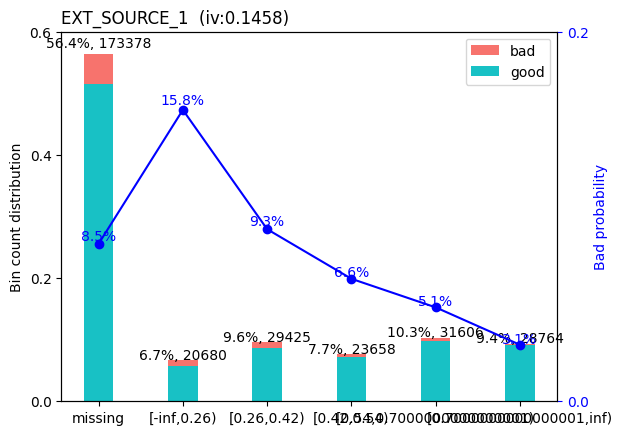

In [14]:
sc.woebin_plot(bins['EXT_SOURCE_1'])

In [15]:
# 3. WOE Transformation

# This transforms raw data into Weight of Evidence values, 

# linearizing the relationship with the log-odds of default.

train_woe = sc.woebin_ply(app_train[selected_vars + ['TARGET']], bins)

test_woe = sc.woebin_ply(app_test[selected_vars], bins)

[INFO] converting into woe values ...
Woe transformating on 307511 rows and 31 columns in 00:00:21
[INFO] converting into woe values ...


In [16]:
train_woe.head()

,TARGET,AMT_ANNUITY_woe,APARTMENTS_AVG_woe,EXT_SOURCE_1_woe,LIVINGAREA_MEDI_woe,NONLIVINGAREA_AVG_woe,DAYS_EMPLOYED_woe,BASEMENTAREA_MODE_woe,NONLIVINGAREA_MEDI_woe,LIVINGAREA_AVG_woe,...,TOTALAREA_MODE_woe,AMT_INCOME_TOTAL_woe,LIVINGAREA_MODE_woe,LANDAREA_MEDI_woe,DAYS_ID_PUBLISH_woe,DAYS_LAST_PHONE_CHANGE_woe,BASEMENTAREA_MEDI_woe,LANDAREA_AVG_woe,BASEMENTAREA_AVG_woe,COMMONAREA_MEDI_woe
0,1,0.120372,0.094688,0.756958,0.114585,-0.129922,0.357089,-0.154681,-0.132942,0.116309,...,0.107398,0.046211,0.100767,-0.100554,0.096645,-0.195462,-0.131018,-0.102337,-0.143356,-0.119009
1,0,0.120372,-0.207758,0.156342,-0.107621,-0.221549,0.182865,-0.154681,-0.170180,-0.091742,...,-0.142686,-0.147199,-0.119626,-0.021804,0.222250,0.145564,-0.131018,-0.026041,-0.143356,-0.212522
2,0,-0.147931,0.137447,0.058722,0.136092,0.123062,0.357089,0.108159,0.123062,0.136092,...,0.147084,0.046211,0.136092,0.096642,0.096645,0.145564,0.108159,0.096642,0.108159,0.065718
3,0,0.120372,0.137447,0.058722,0.136092,0.123062,-0.137674,0.108159,0.123062,0.136092,...,0.147084,0.046211,0.136092,0.096642,0.096645,0.145564,0.108159,0.096642,0.108159,0.065718
4,0,0.120372,0.137447,0.058722,0.136092,0.123062,-0.137674,0.108159,0.123062,0.136092,...,0.147084,0.046211,0.136092,0.096642,-0.023391,-0.195462,0.108159,0.096642,0.108159,0.065718



### 3.2 Pipeline B: Geometry-based Analysis (For Clustering & Trees)
Methodology： Imputation & Standardization.

Methodology: Median Imputation & Z-score Standardization.

Procedure: We performed Median Imputation to handle missing values, followed by One-Hot Encoding for categorical variables and Standard Scaling for numerical features on the df_clean dataset.

Deliverable: X_train_scaled,X_test_scaled

Rationale: Unlike the Scorecard model, geometry-based algorithms such as K-Means Clustering rely on calculating Euclidean distances. Therefore, it is mandatory to fill missing values to prevent data point exclusion and apply Scaling to ensure that features with larger magnitudes (e.g., AMT_INCOME_TOTAL) do not disproportionately dominate the distance metrics.



3.2.1 Imputation



In [17]:
# --- 3.2.1 Imputation Phase ---

# 1. Handle Numerical Missing Values
# Identify numerical columns in the training set
numeric_cols = app_train.select_dtypes(include=['number']).columns

# Calculate the Median from the Training Set ONLY to prevent data leakage
train_median = app_train[numeric_cols].median()

# Fill missing values in Training Set using Training Median
app_train[numeric_cols] = app_train[numeric_cols].fillna(train_median)

# Fill missing values in Test Set using Training Median
# Note: We align the columns to ensure we only fill features present in the Test set (e.g., excluding 'TARGET')
test_cols_to_fill = [col for col in numeric_cols if col in app_test.columns]
app_test[test_cols_to_fill] = app_test[test_cols_to_fill].fillna(train_median[test_cols_to_fill])

# 2. Handle Categorical Missing Values
# Identify categorical (object) columns in the training set and fill with 'Unknown'
char_cols_train = app_train.select_dtypes(include=['object']).columns
app_train[char_cols_train] = app_train[char_cols_train].fillna('Unknown')

# Identify categorical (object) columns in the test set and fill with 'Unknown'
char_cols_test = app_test.select_dtypes(include=['object']).columns
app_test[char_cols_test] = app_test[char_cols_test].fillna('Unknown')


3.2.2 Encoding: Label / One-Hot Encoding



In [18]:
from sklearn.preprocessing import LabelEncoder

# --- Option 1: One-Hot Encoding (Recommended for Clustering) ---
# We use pd.get_dummies for its simplicity and automatic column naming
# 'drop_first=True' reduces multicollinearity by removing one redundant column per feature
app_train_B = pd.get_dummies(app_train, columns=char_cols_train, drop_first=True)
app_test_B = pd.get_dummies(app_test, columns=char_cols_test, drop_first=True)

# Align the Train and Test dataframes
# This ensures both sets have the exact same columns after encoding
# (e.g., if a category exists in Train but not in Test)
app_train_B, app_test_B = app_train_B.align(app_test_B, join='left', axis=1, fill_value=0)

# --- Option 2: Label Encoding (Alternative for Tree-based models) ---
# Only use this if you want to keep the number of columns limited
# le = LabelEncoder()
# for col in char_cols_train:
#     app_train[col] = le.fit_transform(app_train[col])
#     # We handle unseen labels in test set if necessary
#     app_test[col] = app_test[col].map(lambda s: '<unknown>' if s not in le.classes_ else s)
#     le.classes_ = np.append(le.classes_, '<unknown>')
#     app_test[col] = le.transform(app_test[col])

print(f"Encoding complete. Feature count: {app_train_B.shape[1]}")

Encoding complete. Feature count: 187


3.2.3 Scaling

In [19]:

from sklearn.preprocessing import StandardScaler

# Ensure we don't scale the TARGET column
X_train_final = app_train_B.drop(columns=['TARGET'])
X_test_final = app_test_B.drop(columns=['TARGET'], errors='ignore')

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit on Training data and transform both sets to prevent data leakage
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_final), columns=X_train_final.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_final), columns=X_test_final.columns)

X_train_scaled.describe().round(2)

,SK_ID_CURR,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,...,HOUSETYPE_MODE_terraced house,WALLSMATERIAL_MODE_Mixed,WALLSMATERIAL_MODE_Monolithic,WALLSMATERIAL_MODE_Others,WALLSMATERIAL_MODE_Panel,"WALLSMATERIAL_MODE_Stone, brick",WALLSMATERIAL_MODE_Unknown,WALLSMATERIAL_MODE_Wooden,EMERGENCYSTATE_MODE_Unknown,EMERGENCYSTATE_MODE_Yes
count,307511.00,307511.00,307511.00,307511.00,307511.00,307511.00,307511.00,307511.00,307511.00,307511.00,...,307511.00,307511.00,307511.00,307511.00,307511.00,307511.00,307511.00,307511.00,307511.00,307511.00
mean,-0.00,-0.00,-0.00,-0.00,-0.00,0.00,0.00,0.00,0.00,-0.00,...,0.00,-0.00,-0.00,-0.00,0.00,-0.00,-0.00,0.00,-0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,...,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.73,-0.58,-0.60,-1.38,-1.76,-1.35,-1.49,-2.11,-7.33,-5.59,...,-0.06,-0.09,-0.08,-0.07,-0.52,-0.52,-1.02,-0.13,-0.95,-0.09
25%,-0.87,-0.58,-0.24,-0.82,-0.73,-0.81,-0.79,-0.84,-0.24,-0.71,...,-0.06,-0.09,-0.08,-0.07,-0.52,-0.52,-1.02,-0.13,-0.95,-0.09
50%,0.00,-0.58,-0.09,-0.21,-0.15,-0.24,-0.15,0.07,0.28,0.14,...,-0.06,-0.09,-0.08,-0.07,-0.52,-0.52,0.98,-0.13,-0.95,-0.09
75%,0.87,0.81,0.14,0.52,0.52,0.38,0.56,0.83,0.62,0.84,...,-0.06,-0.09,-0.08,-0.07,-0.52,-0.52,0.98,-0.13,1.05,-0.09
max,1.73,25.73,492.70,8.57,15.93,9.51,3.73,1.96,1.05,1.42,...,15.90,11.53,13.11,13.72,1.91,1.94,0.98,7.51,1.05,11.45


## Section 4: Model Implementation
4.1 Logistic Regression
* Data Source: train_woe



In [20]:
# Append the _woe suffix to all selected variables.
selected_vars_woe = [var + '_woe' for var in selected_vars]

# 1. prepare data
X_train = train_woe[selected_vars_woe]
y_train = train_woe['TARGET']
X_test = test_woe[selected_vars_woe]

# 2. Logistic Regression Baseline
#To address the significant class imbalance (only 8.07% default rate), 
#we implemented a cost-sensitive learning approach by setting class_weight='balanced'. 
#This adjustment penalizes the misclassification of the minority class more heavily,
#ensuring the model prioritizes the identification of high-risk borrowers rather than simply optimizing for global accuracy.
lr_baseline = LogisticRegression(C=1, class_weight='balanced', random_state=42)
lr_baseline.fit(X_train, y_train)

# 3.predict probability
train_probs = lr_baseline.predict_proba(X_train)[:, 1]
test_probs = lr_baseline.predict_proba(X_test)[:, 1]

# 4. AUC & KS
auc_val = roc_auc_score(y_train, train_probs)
fpr, tpr, thresholds = roc_curve(y_train, train_probs)
ks_val = max(tpr - fpr)

# 5. PSI 
def calculate_psi(expected, actual, buckets=10):
    expected_percents = np.histogram(expected, bins=buckets)[0] / len(expected)
    actual_percents = np.histogram(actual, bins=buckets)[0] / len(actual)
    expected_percents = np.clip(expected_percents, 0.0001, 1)
    actual_percents = np.clip(actual_percents, 0.0001, 1)
    return np.sum((expected_percents - actual_percents) * np.log(expected_percents / actual_percents))

psi_val = calculate_psi(train_probs, test_probs)

print(f"--- Baseline Model (WOE + LogReg) ---")
print(f"Selected Features: {len(selected_vars)}")
print(f"ROC-AUC: {auc_val:.4f}")
print(f"KS Statistic: {ks_val:.4f}")
print(f"PSI Score: {psi_val:.4f}")

--- Baseline Model (WOE + LogReg) ---
Selected Features: 31
ROC-AUC: 0.7291
KS Statistic: 0.3387
PSI Score: 0.0016


4.2 Classification Trees
* Data Source: X_train_scaled

4.3 Cluster Analysis
* Data Source: X_train_scaled